# Predictability of the 2021 PNW heatwave

Ensemble maximum 2 m temperature over 27-30 June against ERA5, the ensemble-mean
2 m temperature difference from ERA5 over 28-30 June (PDT), and the same
difference in total column water vapour on 25 June.

In [1]:
import dask
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import numpy as np
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri as cm
import os
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import warnings
from cmcrameri import cm
import cfgrib

import babet as bb
import atmicp

warnings.filterwarnings("ignore", category=FutureWarning)
dask.config.set(**{'array.slicing.split_large_chunks': True})

In [2]:
atmicp.style.set_style()

# climate scenario colours from the shared style
CLIM = {'pi': atmicp.style.climate_color('1870'),        # blue
        'curr': atmicp.style.climate_color('present'),   # grey
        'incr': atmicp.style.climate_color('future1')}   # orange

LABEL = {'pi': 'pre-industrial', 'curr': 'current', 'incr': 'increased'}

# one linestyle per perturbation, so climate stays the only thing colour encodes
LS = {'iterated': '-',
      'iterated_short': ':',
      'tq': '--',
      'ocean': '-.',
      'none': '-'}

PERT_LABEL = {'iterated': 'iterated',
              'iterated_short': 'iterated, short',
              'tq': 'delta t+q',
              'ocean': 'ocean only',
              'none': 'unperturbed'}

# Import data

`get_ifs_data` loads the 18/22/26 June initialisations of the iterated run set.
Experiments that have not been retrieved yet are skipped with a warning.

In [3]:
ifs = atmicp.Data.get_ifs_data(levtype='sfc', res='US025')
ifs

Loading 2 file(s) for b2vj (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


/home/e/ermis/ATMICP/atmicp/data.py:244: UserWarning: b2vj: missing inidates ['b2vj_2021-06-26.nc'] in /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf
  warnings.warn(


Loading 2 file(s) for b2vj (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf


/home/e/ermis/ATMICP/atmicp/data.py:244: UserWarning: b2vj: missing inidates ['b2vj_2021-06-26.nc'] in /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
  warnings.warn(


Loading 3 file(s) for b2vl (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf


/home/e/ermis/ATMICP/atmicp/data.py:180: UserWarning: No files found for b2vr (pi, US025, sfc) on the requested inidates - skipping this experiment.
  warnings.warn(


Loading 3 file(s) for b2vl (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2vo (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/cf
Loading 3 file(s) for b2vo (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/pi/US025/sfc/pf
Loading 3 file(s) for b2ut (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/US025/sfc/cf
Loading 3 file(s) for b2ut (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/curr/US025/sfc/pf
Loading 3 file(s) for b2vk (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf
Loading 3 file(s) for b2vk (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf
Loading 3 file(s) for b2vm (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf


/home/e/ermis/ATMICP/atmicp/data.py:180: UserWarning: No files found for b2vq (incr, US025, sfc) on the requested inidates - skipping this experiment.
  warnings.warn(


Loading 3 file(s) for b2vm (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf
Loading 3 file(s) for b2vn (cf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/cf
Loading 3 file(s) for b2vn (pf) from /gf5/predict/AWH019_ERMIS_ATMICP/ITERATION/MED-R/EXP/incr/US025/sfc/pf


<xarray.Dataset> Size: 150GB
Dimensions:       (climate: 3, perturbation: 4, time: 105, number: 51,
                   inidate: 3, latitude: 161, longitude: 201)
Coordinates:
  * climate       (climate) object 24B 'pi' 'curr' 'incr'
  * perturbation  (perturbation) object 32B 'iterated' 'none' 'ocean' 'tq'
  * time          (time) datetime64[ns] 840B 2021-06-18 ... 2021-07-01
  * number        (number) int64 408B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
  * inidate       (inidate) datetime64[ns] 24B 2021-06-18 2021-06-22 2021-06-26
  * latitude      (latitude) float32 644B 70.0 69.75 69.5 ... 30.5 30.25 30.0
  * longitude     (longitude) float32 804B -150.0 -149.8 ... -100.2 -100.0
Data variables:
    t2m           (climate, perturbation, time, number, inidate, latitude, longitude) float64 50GB dask.array<chunksize=(1, 1, 41, 1, 1, 161, 201), meta=np.ndarray>
    msl           (climate, perturbation, time, number, inidate, latitude, longitude) float64 50GB dask.array<chunksize=(1, 1, 41, 1, 1, 161, 201), meta=np.ndarray>
    tcwv          (climate, perturbation, time, number, inidate, latitude, longitude) float64 50GB dask.array<chunksize=(1, 1, 41, 1, 1, 161, 201), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      2026-08-20 17:53:24 GMT by grib_to_netcdf-2.47.1: /opt/ecmw...

In [4]:
# hourly ERA5 t2m on the same grid and domain as the IFS retrievals
era5 = atmicp.Data.get_era5_sfc(var='t2m')
era5

<xarray.Dataset> Size: 93MB
Dimensions:    (time: 720, latitude: 161, longitude: 201)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2021-06-01 ... 2021-06-30T23:00:00
  * latitude   (latitude) float64 1kB 70.0 69.75 69.5 69.25 ... 30.5 30.25 30.0
  * longitude  (longitude) float64 2kB -150.0 -149.8 -149.5 ... -100.2 -100.0
Data variables:
    t2m        (time, latitude, longitude) float32 93MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-19T14:11 GRIB to CDM+CF via cfgrib-0.9.1...

# Exceedance probability of maximum 2m temperature, 27-30 June

Area-averaged over the PNW box, then the maximum over the window for each
ensemble member. The empirical distribution is drawn the other way up from a
cumulative one: the x axis is the exceedance probability P(max > t) on a log
scale, so the rare tail the heatwave sits in is spread out on the right rather
than squashed into the corner of an ECDF. ERA5 is a single value rather than a
distribution, so it is drawn as a dashed horizontal line.

In [5]:
pnw = atmicp.Constants.pnw
box = dict(longitude=slice(pnw[0], pnw[1]), latitude=slice(pnw[3], pnw[2]))
window = slice('2021-06-27', '2021-06-30T23')

# per-member maximum over the window, area-averaged over the PNW box
tmax = (ifs.t2m.sel(**box).mean(['latitude', 'longitude'])
        .sel(time=window).max('time').compute() - 273.15)

era5_tmax = float(era5.t2m.sel(**box).mean(['latitude', 'longitude'])
                  .sel(time=window).max('time') - 273.15)

print(f'ERA5 max t2m over the PNW box, 27-30 June: {era5_tmax:.2f} degC')

/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


ERA5 max t2m over the PNW box, 27-30 June: 38.51 degC


In [6]:
# which (climate, perturbation) combinations actually ran? the concat NaN-fills
# the rest, and this is cheap now that tmax is a small array
present = [(str(c), str(p))
           for c in ifs.climate.values for p in ifs.perturbation.values
           if bool(tmax.sel(climate=c, perturbation=p).notnull().any())]
present

[('pi', 'iterated'),
 ('pi', 'ocean'),
 ('pi', 'tq'),
 ('curr', 'none'),
 ('incr', 'iterated'),
 ('incr', 'ocean'),
 ('incr', 'tq')]

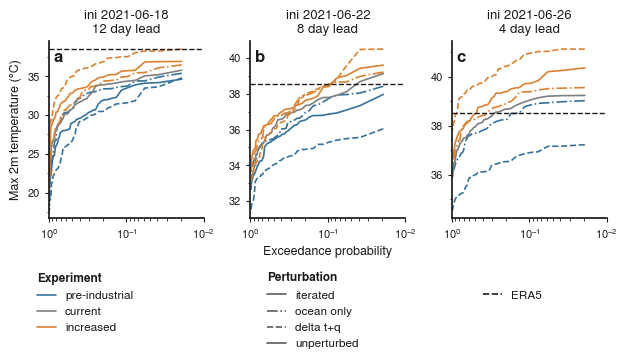

In [7]:
ncol = len(tmax.inidate)


def exceedance(values):
    """Empirical exceedance probability P(max t2m > t) for each member.

    Weibull plotting positions k/(n+1) rather than the complementary ECDF,
    which puts the largest member at exactly zero and so cannot be drawn on a
    log axis. The rarest member of n sits at 1/(n+1): one over one more than
    the ensemble size is as far into the tail as n members can resolve.
    """
    t = np.sort(np.asarray(values))[::-1]            # largest member first
    return np.arange(1, t.size + 1) / (t.size + 1), t


# drawn on the style.py reference canvas, so the sizes quoted there are the
# sizes the figure prints at; scaled() keeps that true if the canvas changes
fig = plt.figure(figsize=(atmicp.style.REF_WIDTH, 2.3))
gs = fig.add_gridspec(1, ncol, wspace=0.3)

axes = []
pmin = 1.0
for i, inidate in enumerate(tmax.inidate.values):
    # shared x only: each lead time keeps its own temperature range
    ax = fig.add_subplot(gs[0, i], sharex=axes[0] if axes else None)
    axes.append(ax)

    for climate, pert in present:
        da = tmax.sel(inidate=inidate, climate=climate, perturbation=pert).dropna('number')
        if da.size == 0:
            continue
        p, t = exceedance(da.values)
        pmin = min(pmin, p[0])
        ax.plot(p, t, color=CLIM[climate], linestyle=LS[pert], linewidth=1.2)

    ax.axhline(era5_tmax, color=atmicp.style.INK, linestyle='--', linewidth=1.0, zorder=10)

    lead = (pd.Timestamp('2021-06-30') - pd.Timestamp(inidate)).days
    ax.set_title(f'ini {np.datetime_as_string(inidate, unit="D")}\n{lead} day lead',
                 fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig))
    # one x label under the middle panel, one y label on the left; the
    # temperature ticks stay on every panel now that each has its own range
    ax.set_xlabel('Exceedance probability' if i == ncol // 2 else '',
                  fontsize=atmicp.style.scaled(atmicp.style.FS_LABEL, fig))
    ax.set_ylabel('Max 2m temperature (°C)' if i == 0 else '',
                  fontsize=atmicp.style.scaled(atmicp.style.FS_LABEL, fig))
    # the shared style draws no tick marks; both axes carry them here, with
    # minor ticks resolving the decades of the probability axis
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.tick_params(which='major', bottom=True, left=True, length=3, width=0.8,
                   labelsize=atmicp.style.scaled(atmicp.style.FS_TICK, fig))
    ax.tick_params(which='minor', bottom=True, left=True, length=1.8, width=0.6)
    sns.despine(ax=ax)

# probability decreasing to the right (left limit above right limit), so the
# ensemble tail reads left to right and the curves rise into it. The axis runs
# to the decade below 1/(n+1), the rarest member the ensemble resolves, so that
# both ends of it land on a labelled decade.
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlim(1.0, 10 ** np.floor(np.log10(pmin)))
    # labelled decades in scientific notation; the sub-decade positions are
    # left to the minor tick marks, which keeps the labels short enough for
    # a panel this narrow
    ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.xaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

atmicp.style.panel_labels(axes)

# legend under the panels, one block per encoding. The blocks are top aligned,
# so ERA5 -- which belongs under neither heading -- carries a blank title of the
# same size to keep its entry level with the entries beside it.
fs_legend = atmicp.style.scaled(atmicp.style.FS_ANNOT, fig)
heading = {'size': fs_legend, 'weight': 'bold'}


def entry(color, linestyle, label):
    return Line2D([0], [0], color=color, linestyle=linestyle, linewidth=1.2,
                  label=label)


blocks = [
    ('Experiment',
     [entry(CLIM[c], '-', LABEL[c])
      for c in ['pi', 'curr', 'incr'] if c in ifs.climate.values]),
    ('Perturbation',
     [entry(atmicp.style.MUTED, LS[p], PERT_LABEL[p])
      for p in dict.fromkeys(p for _, p in present)]),
    (' ',
     [entry(atmicp.style.INK, '--', 'ERA5')]),
]

for x, (title, handles) in zip([0.10, 0.42, 0.72], blocks):
    fig.legend(handles=handles, title=title, loc='upper left',
               bbox_to_anchor=(x, -0.10), bbox_transform=fig.transFigure,
               frameon=False, alignment='left', fontsize=fs_legend,
               title_fontproperties=heading, handlelength=1.6,
               labelspacing=0.5, borderpad=0.0)

atmicp.style.save(fig, '08_ecdf_tmax_pnw')
plt.show()

# Difference maps against ERA5

`diff_map_grid` draws one row per (climate, perturbation) and one column per
initialisation date, so the two figures below stay identical apart from the
field, the days and the colour ramp.

Two things this section is careful about. The heatwave sat on PDT (UTC-7), so a
UTC calendar day is not a local day: `pdt_steps` picks the 3-hourly steps whose
*local* time falls on the requested dates. And only the current-climate
unperturbed row is a forecast bias -- the pre-industrial and increased rows
differ from ERA5 by their imposed climate perturbation as well as by forecast
error, so these figures say "minus ERA5" rather than "bias".

In [13]:
# --- local days -------------------------------------------------------------
PDT = np.timedelta64(7, 'h')


def pdt_steps(ifs_times, era5_times, days):
    """UTC timestamps on the given PDT dates that both datasets carry.

    The forecasts stop at 2021-07-01T00Z and the ERA5 file at 2021-06-30T23Z,
    so a window running to the end of 30 June comes back short rather than
    raising; `diff_vs_era5` reports what it actually got.
    """
    on_day = np.isin((ifs_times.to_index() - PDT).normalize(),
                     [np.datetime64(d) for d in days])
    steps = ifs_times.values[on_day]
    return steps[np.isin(steps, era5_times.values)]


def diff_vs_era5(ifs_da, era5_da, days, label=''):
    """Ensemble-mean IFS minus ERA5, averaged over the PDT days in `days`.

    The difference is taken step by step and only then averaged, and any run
    that does not cover the whole window is dropped. Both matter once `days`
    spans a local rather than a UTC day: the 26 June initialisation reaches
    only the last two steps of the 25 June PDT day, and averaging those two
    against a full-day ERA5 mean would compare different parts of the diurnal
    cycle.
    """
    steps = pdt_steps(ifs_da.time, era5_da.time, days)

    # grids match exactly, so this differences without regridding
    assert np.array_equal(ifs_da.latitude.values, era5_da.latitude.values)
    assert np.array_equal(ifs_da.longitude.values, era5_da.longitude.values)

    local = pd.to_datetime(steps) - PDT
    print(f'{label}{len(steps)} steps, PDT '
          f'{local[0]:%d %b %H:%M} to {local[-1]:%d %b %H:%M}')
    for d in days:
        n = int((local.normalize() == pd.Timestamp(d)).sum())
        short = '' if n == 8 else '   <- short: the forecasts/ERA5 end here'
        print(f'   PDT {d}: {n}/8 steps{short}')

    ifs_w = ifs_da.sel(time=steps)
    diff = (ifs_w - era5_da.sel(time=steps)).mean('time').mean('number')

    # steps each run actually carries. A run the concat did not reach is NaN
    # over the whole field, so one grid point is enough to count them.
    cover = (ifs_w.isel(latitude=0, longitude=0)
             .notnull().sum('time').max('number').compute())
    for c in cover.climate.values:
        for p in cover.perturbation.values:
            for i in cover.inidate.values:
                k = int(cover.sel(climate=c, perturbation=p, inidate=i))
                if 0 < k < len(steps):
                    print(f'   dropping {c}/{p} ini '
                          f'{np.datetime_as_string(i, unit="D")}: only '
                          f'{k}/{len(steps)} steps inside the window')

    return diff.where(cover == len(steps)).compute()


# --- the figure -------------------------------------------------------------
def diff_map_grid(diff, cbar_label, title, stem, cmap=cm.vik, note=None):
    """Grid of ensemble-mean difference maps against ERA5.

    One row per (climate, perturbation) in `present`, one column per inidate in
    `diff`. Sizes come from atmicp.style: the canvas is at most the reference
    width and the panel height follows the aspect of the plotted domain.

    Each column carries its own symmetric colour limit and its own colourbar.
    The columns are different lead times and their errors differ by an order of
    magnitude, so a single scale across the figure saturates the long-lead
    column and leaves the short-lead one blank.
    """
    inidates = diff.inidate.values
    rows = [(c, p) for c, p in present
            if bool(diff.sel(climate=c, perturbation=p).notnull().any())]
    ncol, nrow = len(inidates), len(rows)

    lon0, lon1, lat0, lat1 = atmicp.Constants.west_coast
    # a grid with fewer than three columns keeps the panel size of a
    # three-column one rather than stretching to the reference width; scaled()
    # then sets the type for the narrower canvas
    panel_w = atmicp.style.REF_WIDTH / max(ncol, 3)
    panel_h = panel_w * (lat1 - lat0) / (lon1 - lon0)

    # one symmetric limit per column, off the 99th percentile of that column
    vlim = {}
    for inidate in inidates:
        col = np.abs(diff.sel(inidate=inidate).values)
        col = col[np.isfinite(col)]
        vlim[inidate] = max(float(np.ceil(np.percentile(col, 99))), 1.0)
    print('colour limits: ' + ', '.join(
        f'{np.datetime_as_string(d, unit="D")} +-{vlim[d]:.0f}' for d in inidates))

    fig = plt.figure(figsize=(panel_w * ncol, panel_h * nrow + 1.0))
    gs = gridspec.GridSpec(nrow, ncol, wspace=0.06, hspace=0.08,
                           top=0.94, bottom=0.11)

    axes, col_axes, col_mesh = [], {c: [] for c in range(ncol)}, {}
    for r, (climate, pert) in enumerate(rows):
        for c, inidate in enumerate(inidates):
            ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
            axes.append(ax)
            col_axes[c].append(ax)
            ax.set_extent(atmicp.Constants.west_coast, crs=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE.with_scale('50m'), color='gray',
                           linewidth=0.5, zorder=14)

            da = diff.sel(climate=climate, perturbation=pert, inidate=inidate)
            if not bool(da.notnull().any()):
                # not retrieved, or too little of it falls inside the window
                ax.text(0.5, 0.5, 'not available', transform=ax.transAxes,
                        ha='center', va='center', color=atmicp.style.MUTED,
                        fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig))
            col_mesh[c] = ax.pcolormesh(
                da.longitude, da.latitude, da, cmap=cmap,
                vmin=-vlim[inidate], vmax=vlim[inidate],
                transform=ccrs.PlateCarree())

            # the PNW box the ECDF above averages over
            ax.add_patch(patches.Rectangle(
                (pnw[0], pnw[2]), pnw[1] - pnw[0], pnw[3] - pnw[2],
                linewidth=1.0, edgecolor='white', facecolor='none',
                transform=ccrs.PlateCarree(), zorder=17))

            if r == 0:
                ax.set_title(f'ini {np.datetime_as_string(inidate, unit="D")}',
                             fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig))
            if c == 0:
                # far enough out that the second line clears the panel edge
                ax.text(-0.12, 0.5, f'{LABEL[climate]}\n{PERT_LABEL[pert]}',
                        transform=ax.transAxes, rotation=90, va='center', ha='center',
                        fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig),
                        color=CLIM[climate], zorder=20)

    # panel labels a, b, c ... with a white halo, so they stay legible over the
    # dark ends of the colour ramp
    atmicp.style.panel_labels(
        axes, x=0.04, y=0.96,
        path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])

    # one colourbar per column, placed under the column it belongs to; the
    # panels are cartopy axes with a fixed aspect, so their final positions are
    # only known after a draw
    fig.canvas.draw()
    cbar_bottom = []
    for c, inidate in enumerate(inidates):
        pos = [ax.get_position() for ax in col_axes[c]]
        x0, x1 = min(p.x0 for p in pos), max(p.x1 for p in pos)
        y0 = min(p.y0 for p in pos)
        cax = fig.add_axes([x0 + 0.12 * (x1 - x0), y0 - 0.050,
                            0.76 * (x1 - x0), 0.010])
        cbar_bottom.append(y0 - 0.050)
        cbar = fig.colorbar(col_mesh[c], cax=cax, orientation='horizontal',
                            extend='both')
        cbar.ax.tick_params(labelsize=atmicp.style.scaled(atmicp.style.FS_XSMALL, fig))

    # one label for all of them, centred on the canvas rather than hung off
    # whichever column happens to be the middle one
    fig.text(0.5, min(cbar_bottom) - 0.028, cbar_label, ha='center', va='top',
             fontsize=atmicp.style.scaled(atmicp.style.FS_SMALL, fig))

    fig.suptitle(title, fontsize=atmicp.style.scaled(atmicp.style.FS_TITLE, fig), y=0.975)
    if note:
        fig.text(0.5, 0.008, note, ha='center', va='bottom', wrap=True,
                 fontsize=atmicp.style.scaled(atmicp.style.FS_XSMALL, fig),
                 color=atmicp.style.MUTED)

    atmicp.style.save(fig, stem)
    return

## 2 m temperature, 28-30 June (PDT)

Ensemble mean minus ERA5, averaged over the three local days spanning the peak
of the heatwave. ERA5 is subsampled onto the IFS 3-hourly steps first, so the
two means average the same points of the diurnal cycle.

30 June comes out short: the forecasts stop at 2021-07-01T00Z and the ERA5 file
at 2021-06-30T23Z, so that day is only covered to 14:00 PDT. Both sides are
averaged over exactly the same timestamps, so this shortens the window rather
than biasing the difference.

In [14]:
days = ['2021-06-28', '2021-06-29', '2021-06-30']

diff_t2m = diff_vs_era5(ifs.t2m, era5.t2m, days, label='2m temperature: ')

# how large the differences actually are, before the colour scale rounds them
print(f'\nmax |difference|: {float(np.nanmax(np.abs(diff_t2m))):.2f} K')
print('PNW-box mean difference (K):')
for c, p in present:
    row = diff_t2m.sel(climate=c, perturbation=p)
    print(f'  {c + "/" + p:16s}' + '  '.join(
        f'ini {np.datetime_as_string(d, unit="D")} {float(row.sel(inidate=d).sel(**box).mean()):+6.2f}'
        for d in row.inidate.values))

2m temperature: 21 steps, PDT 28 Jun 02:00 to 30 Jun 14:00
   PDT 2021-06-28: 8/8 steps
   PDT 2021-06-29: 8/8 steps
   PDT 2021-06-30: 5/8 steps   <- short: the forecasts/ERA5 end here

max |difference|: 17.07 K
PNW-box mean difference (K):
  pi/iterated     ini 2021-06-18  -9.70  ini 2021-06-22  -3.41  ini 2021-06-26   +nan
  pi/ocean        ini 2021-06-18  -8.84  ini 2021-06-22  -2.88  ini 2021-06-26  -0.51
  pi/tq           ini 2021-06-18 -11.44  ini 2021-06-22  -5.90  ini 2021-06-26  -2.13
  curr/none       ini 2021-06-18  -8.23  ini 2021-06-22  -2.68  ini 2021-06-26  -0.14
  incr/iterated   ini 2021-06-18  -6.91  ini 2021-06-22  -3.11  ini 2021-06-26  -0.53
  incr/ocean      ini 2021-06-18  -7.82  ini 2021-06-22  -2.35  ini 2021-06-26  +0.25
  incr/tq         ini 2021-06-18  -4.46  ini 2021-06-22  -1.75  ini 2021-06-26  +1.62


colour limits: 2021-06-18 +-13, 2021-06-22 +-9, 2021-06-26 +-5


/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

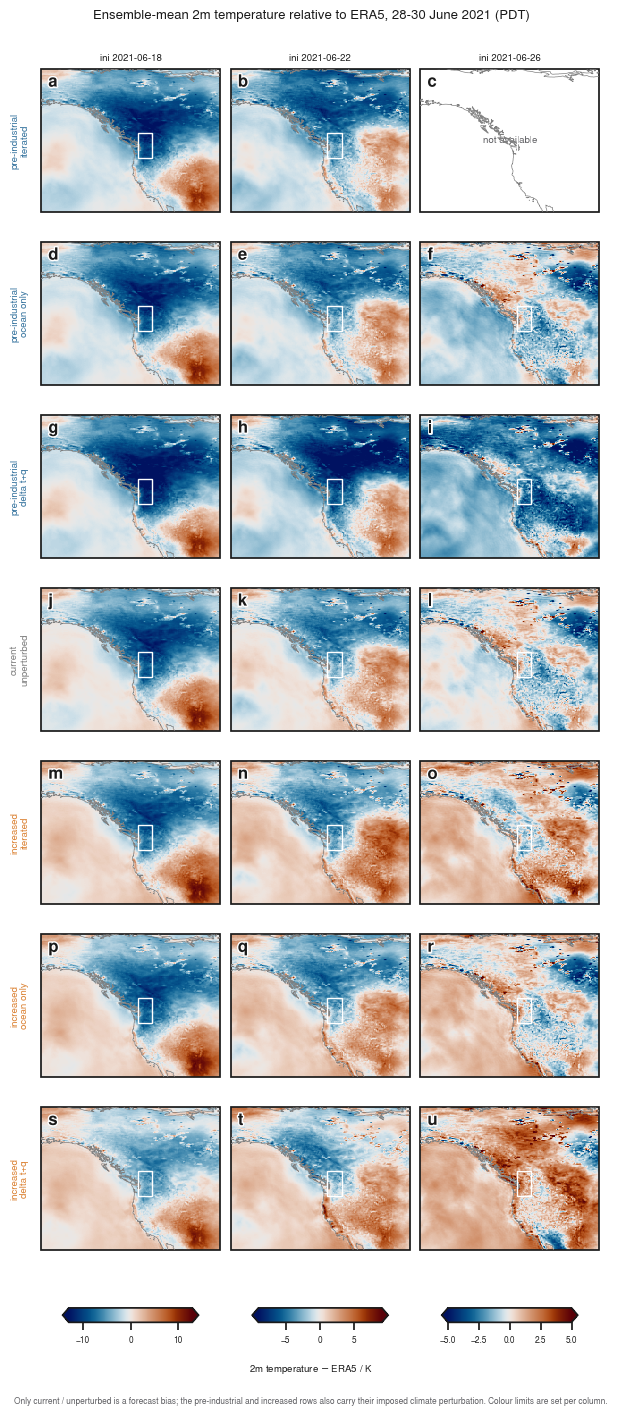

In [15]:
diff_map_grid(diff_t2m,
              cbar_label='2m temperature $-$ ERA5 / K',
              title='Ensemble-mean 2m temperature relative to ERA5, 28-30 June 2021 (PDT)',
              stem='08_diff_map_t2m_pdt_20210628-30',
              note='Only current / unperturbed is a forecast bias; the pre-industrial '
                   'and increased rows also carry their imposed climate perturbation. '
                   'Colour limits are set per column.')

## Total column water vapour, 25 June (PDT)

The moisture difference four days before the peak of the heatwave, on the same
domain and with the same layout as the temperature figure above, over a single
local day.

In [17]:
days_tcwv = ['2021-06-25']

# hourly ERA5 tcwv on the same grid and domain as the IFS retrievals
era5_tcwv = atmicp.Data.get_era5_sfc(var='tcwv')

diff_tcwv = diff_vs_era5(ifs.tcwv, era5_tcwv.tcwv, days_tcwv, label='tcwv: ')

# an initialisation later than these days has nothing left to show
have = [d for d in diff_tcwv.inidate.values
        if bool(diff_tcwv.sel(inidate=d).notnull().any())]
diff_tcwv = diff_tcwv.sel(inidate=have)

print(f'inidates with data: '
      f'{[np.datetime_as_string(d, unit="D") for d in diff_tcwv.inidate.values]}')
print(f'max |difference|: {float(np.nanmax(np.abs(diff_tcwv))):.2f} kg m-2')

tcwv: 8 steps, PDT 25 Jun 02:00 to 25 Jun 23:00
   PDT 2021-06-25: 8/8 steps
   dropping pi/ocean ini 2021-06-26: only 3/8 steps inside the window
   dropping pi/tq ini 2021-06-26: only 3/8 steps inside the window
   dropping curr/none ini 2021-06-26: only 3/8 steps inside the window
   dropping incr/iterated ini 2021-06-26: only 3/8 steps inside the window
   dropping incr/ocean ini 2021-06-26: only 3/8 steps inside the window
   dropping incr/tq ini 2021-06-26: only 3/8 steps inside the window
inidates with data: [np.str_('2021-06-18'), np.str_('2021-06-22')]
max |difference|: 22.34 kg m-2


colour limits: 2021-06-18 +-16, 2021-06-22 +-12


/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/e/ermis/nobackups/miniforge3/envs/atmicp/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it

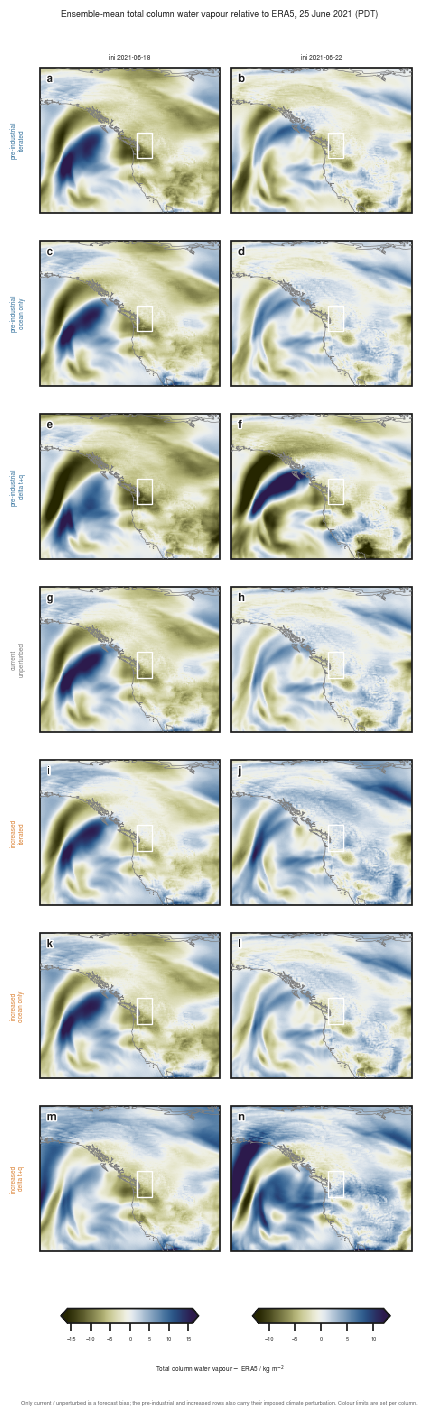

In [18]:
# broc reversed: olive where the forecast is too dry, blue where it is too moist
diff_map_grid(diff_tcwv, cmap=cm.broc_r,
              cbar_label='Total column water vapour $-$ ERA5 / kg m$^{-2}$',
              title='Ensemble-mean total column water vapour relative to ERA5, 25 June 2021 (PDT)',
              stem='08_diff_map_tcwv_pdt_20210625',
              note='Only current / unperturbed is a forecast bias; the pre-industrial '
                   'and increased rows also carry their imposed climate perturbation. '
                   'Colour limits are set per column.')